In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/sample_data/classData.csv')
display(df.head())

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


In [4]:
# Function to combine G, C, B, A into a single 'fault_type' column
def get_fault_type(row):
    faults = []
    if row['G'] == 1:
        faults.append('G')
    if row['C'] == 1:
        faults.append('C')
    if row['B'] == 1:
        faults.append('B')
    if row['A'] == 1:
        faults.append('A')

    if not faults:
        return 'No_Fault'
    return '_'.join(faults) + '_Fault'

df['fault_type'] = df.apply(get_fault_type, axis=1)

print("Value counts for the newly created 'fault_type' column:")
print(df['fault_type'].value_counts())

# Import LabelEncoder and apply it to the 'fault_type' column
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['fault_type_encoded'] = le.fit_transform(df['fault_type'])

print("\nLabel mapping for 'fault_type_encoded':")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

print("\nDataFrame head with the new 'fault_type' and 'fault_type_encoded' columns:")
display(df[['G', 'C', 'B', 'A', 'fault_type', 'fault_type_encoded']].head())

Value counts for the newly created 'fault_type' column:
fault_type
No_Fault         2365
G_B_A_Fault      1134
G_C_B_A_Fault    1133
G_A_Fault        1129
C_B_A_Fault      1096
C_B_Fault        1004
Name: count, dtype: int64

Label mapping for 'fault_type_encoded':
C_B_A_Fault: 0
C_B_Fault: 1
G_A_Fault: 2
G_B_A_Fault: 3
G_C_B_A_Fault: 4
No_Fault: 5

DataFrame head with the new 'fault_type' and 'fault_type_encoded' columns:


,G,C,B,A,fault_type,fault_type_encoded
0,1,0,0,1,G_A_Fault,2
1,1,0,0,1,G_A_Fault,2
2,1,0,0,1,G_A_Fault,2
3,1,0,0,1,G_A_Fault,2
4,1,0,0,1,G_A_Fault,2


In [6]:
columns_to_drop = ['G', 'C', 'B', 'A', 'fault_type']
df = df.drop(columns=columns_to_drop)

print("DataFrame after dropping specified columns:")
display(df.head())

DataFrame after dropping specified columns:


,Ia,Ib,Ic,Va,Vb,Vc,fault_type_encoded
0,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,2
1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,2
2,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,2
3,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,2
4,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7861 entries, 0 to 7860
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   G                   7861 non-null   int64  
 1   C                   7861 non-null   int64  
 2   B                   7861 non-null   int64  
 3   A                   7861 non-null   int64  
 4   Ia                  7861 non-null   float64
 5   Ib                  7861 non-null   float64
 6   Ic                  7861 non-null   float64
 7   Va                  7861 non-null   float64
 8   Vb                  7861 non-null   float64
 9   Vc                  7861 non-null   float64
 10  fault_type          7861 non-null   object 
 11  fault_type_encoded  7861 non-null   int64  
dtypes: float64(6), int64(5), object(1)
memory usage: 737.1+ KB


In [16]:
df['fault_type_encoded'].value_counts()

,count
fault_type_encoded,
5,2365
3,1134
4,1133
2,1129
0,1096
1,1004


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (X) and target (y)
X = df.drop('fault_type_encoded', axis=1)
y = df['fault_type_encoded']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5502, 6)
X_test shape: (2359, 6)
y_train shape: (5502,)
y_test shape: (2359,)


In [18]:
y_train.value_counts()

,count
fault_type_encoded,
5,1649
0,805
4,796
3,781
2,771
1,700


In [19]:
y_test.value_counts()

,count
fault_type_encoded,
5,716
2,358
3,353
4,337
1,304
0,291


In [8]:
# Apply Standard Scaler to the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
# Display first 5 rows of scaled data to confirm
print("First 5 rows of scaled training data (X_train_scaled):")
print(X_train_scaled[:5])

Features scaled successfully.
First 5 rows of scaled training data (X_train_scaled):
[[-1.03769503 -0.82401255  2.2675128  -0.12170642  0.07675266  0.03590529]
 [ 1.6399507   0.26457327 -0.15691225 -0.78063571  0.27547246  0.45094805]
 [-0.01506683  1.47317154 -1.71329158  1.50878292  0.07882875 -1.49360268]
 [ 1.84018045 -1.24853105 -0.80952466  0.06448347 -0.13166466  0.07357959]
 [-0.08944029  1.87755429  0.05153506  0.15315327 -0.71911619  0.58832432]]


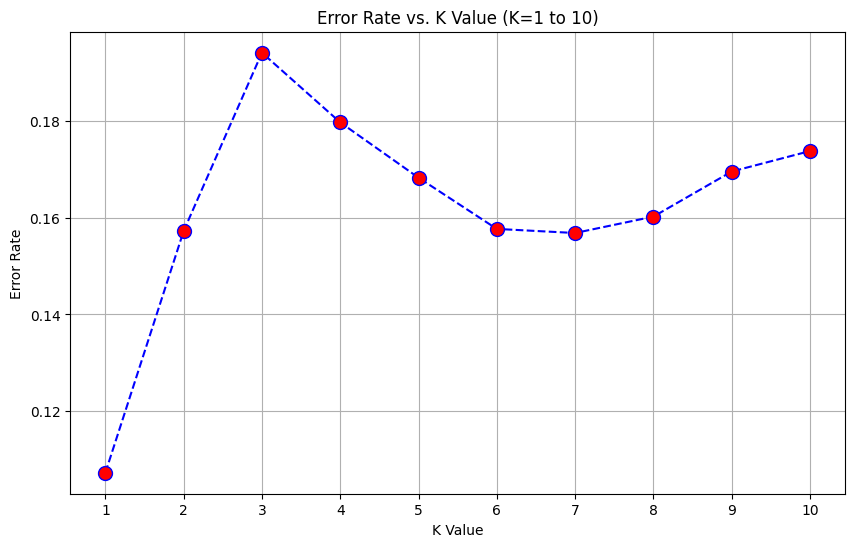

The best K value (from 1 to 10) is: 1


In [25]:
# Determine the best K for KNN
error_rate = []
accuracy_scores = []

# Iterate for K from 1 to 10 as requested by the user
for i in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))
    accuracy_scores.append(accuracy_score(y_test, pred_i))

# Plotting the error rate vs. K value
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value (K=1 to 10)')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(range(1, 11)) # Ensure x-ticks are for each K
plt.grid(True)
plt.show()

# Find the best K based on the minimum error rate within the range 1-10
best_k_index = np.argmin(error_rate)
best_k = range(1, 11)[best_k_index]
print(f"The best K value (from 1 to 10) is: {best_k}")

In [26]:
# Display accuracy for each K value (1 to 10)
print("Accuracy for each K value (1 to 10):")
for k_val, accuracy in zip(range(1, 11), accuracy_scores):
    print(f"K = {k_val}: Accuracy = {accuracy:.4f}")

Accuracy for each K value (1 to 10):
K = 1: Accuracy = 0.8928
K = 2: Accuracy = 0.8427
K = 3: Accuracy = 0.8058
K = 4: Accuracy = 0.8203
K = 5: Accuracy = 0.8317
K = 6: Accuracy = 0.8423
K = 7: Accuracy = 0.8432
K = 8: Accuracy = 0.8398
K = 9: Accuracy = 0.8304
K = 10: Accuracy = 0.8262



KNN Model Evaluation on Test Set with K = 6:

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.70      0.54       291
           1       1.00      1.00      1.00       304
           2       0.97      1.00      0.98       358
           3       0.96      0.98      0.97       353
           4       0.43      0.19      0.26       337
           5       1.00      0.99      1.00       716

    accuracy                           0.84      2359
   macro avg       0.80      0.81      0.79      2359
weighted avg       0.84      0.84      0.83      2359


Confusion Matrix (Test Set):
[[205   0   0   0  86   0]
 [  1 303   0   0   0   0]
 [  0   0 357   1   0   0]
 [  0   0   6 346   0   1]
 [259   0   1  13  64   0]
 [  0   0   4   0   0 712]]


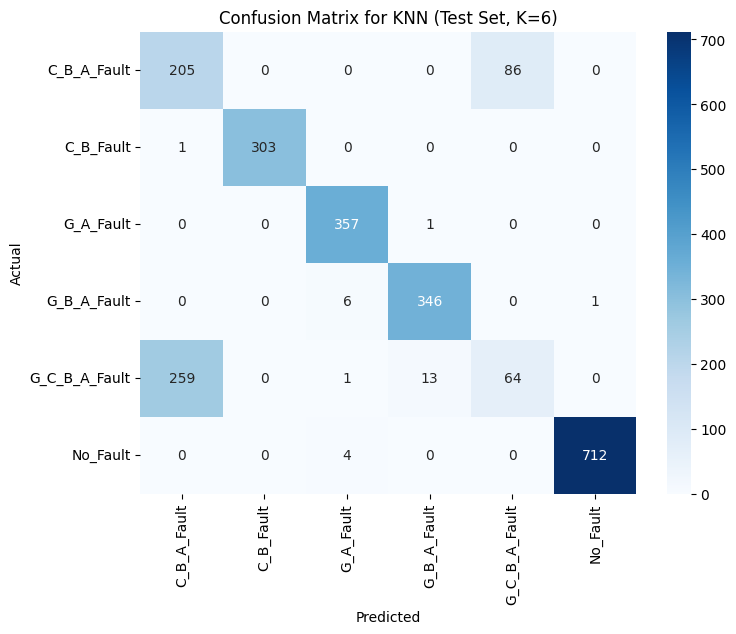


Accuracy Score (Test Set): 0.8423


KNN Model Evaluation on Train Set with K = 6:

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.84      0.68       805
           1       1.00      1.00      1.00       700
           2       0.96      1.00      0.98       771
           3       0.97      0.97      0.97       781
           4       0.66      0.32      0.43       796
           5       1.00      1.00      1.00      1649

    accuracy                           0.87      5502
   macro avg       0.86      0.85      0.84      5502
weighted avg       0.88      0.87      0.86      5502


Confusion Matrix (Train Set):
[[ 674    0    1    0  130    0]
 [   1  699    0    0    0    0]
 [   0    0  771    0    0    0]
 [   0    0   25  756    0    0]
 [ 515    0    1   24  255    1]
 [   0    0    2    0    0 1647]]


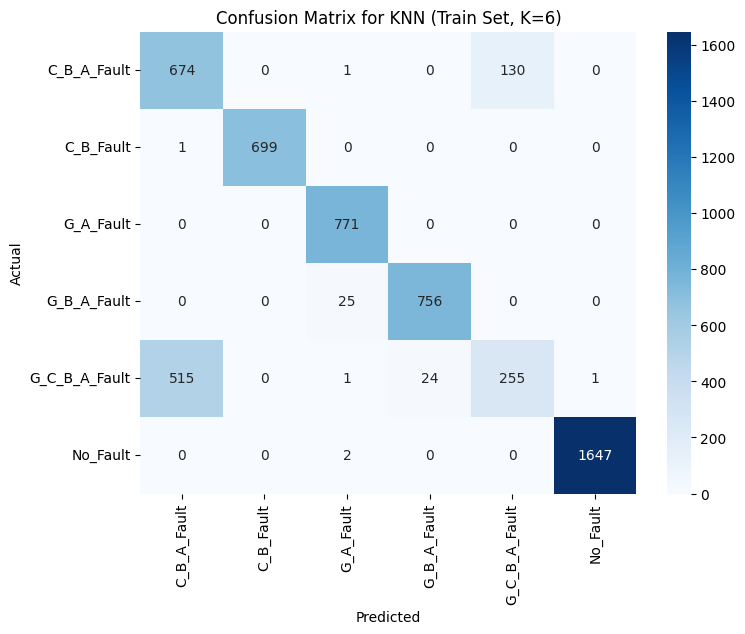


Accuracy Score (Train Set): 0.8728


In [24]:
# Train and evaluate KNN model with the best K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

# Evaluate on Test Set
predictions_test = knn.predict(X_test_scaled)
print(f"\nKNN Model Evaluation on Test Set with K = {best_k}:")
print("\nClassification Report:")
print(classification_report(y_test, predictions_test))

print("\nConfusion Matrix (Test Set):")
cm_test = confusion_matrix(y_test, predictions_test)
print(cm_test)

# Visualize Confusion Matrix for Test Set
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix for KNN (Test Set, K={best_k})')
plt.show()
print(f"\nAccuracy Score (Test Set): {accuracy_score(y_test, predictions_test):.4f}")


# Evaluate on Train Set
predictions_train = knn.predict(X_train_scaled)
print(f"\n\nKNN Model Evaluation on Train Set with K = {best_k}:")
print("\nClassification Report:")
print(classification_report(y_train, predictions_train))

print("\nConfusion Matrix (Train Set):")
cm_train = confusion_matrix(y_train, predictions_train)
print(cm_train)

# Visualize Confusion Matrix for Train Set
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix for KNN (Train Set, K={best_k})')
plt.show()
print(f"\nAccuracy Score (Train Set): {accuracy_score(y_train, predictions_train):.4f}")